# IMDb Sentiment Analysis: Exploratory Data Analysis (EDA)
**Deep Learning Midterm Project**  
This notebook covers all EDA requirements from Section 2.2 of the project spec:
1. Class distribution (bar chart)
2. Sequence length statistics (min, max, mean, 90th percentile)
3. Vocabulary frequency (top-30 token bar chart)
4. Representative samples (3–5 positive and negative reviews)

## 0. Set-up and Import

In [1]:
# Install if needed
# ! pip install datasets

import sys
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from datasets import load_dataset
import random

# Add src folder to path for importing preprocess
sys.path.insert(0, '../src')
from preprocess import (load_imdb_data, clean_text, 
                       analyze_class_distribution, analyze_sequence_lengths, 
                       get_vocab_frequencies, get_representative_samples)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('All imports successful.')

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


## 1. Load Dataset

In [2]:
# Load raw IMDb data (combines train + test splits)
raw_texts, raw_labels = load_imdb_data()

# Clean all texts using the preprocessing module function
cleaned_texts = [clean_text(t) for t in raw_texts]

# Verify loading
print(f'Total samples: {len(raw_texts):,}')
print(f'  Positive: {sum(raw_labels):,}')
print(f'  Negative: {len(raw_labels) - sum(raw_labels):,}')

print(f'\nSample (raw):')
print(f'  {raw_texts[0][:150]}...\n')
print(f'Sample (cleaned):')
print(f'  {cleaned_texts[0][:150]}...')

Total samples: 50,000
  Positive: 25,000
  Negative: 25,000

Sample (raw):
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th...

Sample (cleaned):
  i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard tha...


## 2. Text Cleaning Helper
IMDb reviews contain HTML tags (e.g. `<br />`). We strip them before any analysis.

In [3]:
# The clean_text function is imported from preprocess.py
# It removes HTML tags, keeps letters/digits/spaces, and normalizes to lowercase

# Split labels by sentiment for analysis
positive_texts = [cleaned_texts[i] for i in range(len(raw_labels)) if raw_labels[i] == 1]
negative_texts = [cleaned_texts[i] for i in range(len(raw_labels)) if raw_labels[i] == 0]

print(f'Positive reviews: {len(positive_texts):,}')
print(f'Negative reviews: {len(negative_texts):,}')
print(f'\nDataset is perfectly balanced: {len(positive_texts) == len(negative_texts)}')

Positive reviews: 25,000
Negative reviews: 25,000

Dataset is perfectly balanced: True


## 3. EDA Req-1: Class Distribution

In [1]:
# Analyze class distribution using the preprocessing module
class_stats = analyze_class_distribution(raw_labels)

print('CLASS DISTRIBUTION ANALYSIS')
print('=' * 50)
print(f'Total samples      : {class_stats["total"]:,}')
print(f'Negative (0)       : {class_stats["negative"]:,} ({class_stats["negative_pct"]:.1f}%)')
print(f'Positive (1)       : {class_stats["positive"]:,} ({class_stats["positive_pct"]:.1f}%)')
print(f'Dataset balanced   : {"Yes" if class_stats["balanced"] else "No"}')

# Visualization
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_stats['class_names'], class_stats['counts'], 
              color=['#FF6B6B', '#4ECDC4'], alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_title('Class Distribution — IMDb Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_xlabel('Sentiment Class', fontsize=12)
ax.bar_label(bars, labels=[f'{c:,}\n({p:.1f}%)' for c, p in zip(class_stats['counts'], class_stats['percentages'])], 
             padding=10, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('../results/eda_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ CONCLUSION: Dataset is perfectly balanced (50/50).')
print('  No class weighting or oversampling needed.')

NameError: name 'analyze_class_distribution' is not defined

## 4. EDA Req-2: Sequence Length Statistics

SEQUENCE LENGTH STATISTICS (tokens)
Minimum          : 6
Maximum          : 2,505
Mean             : 235.6
Median           : 177.0
Std Dev          : 174.3
90th percentile  : 459
95th percentile  : 601
99th percentile  : 920


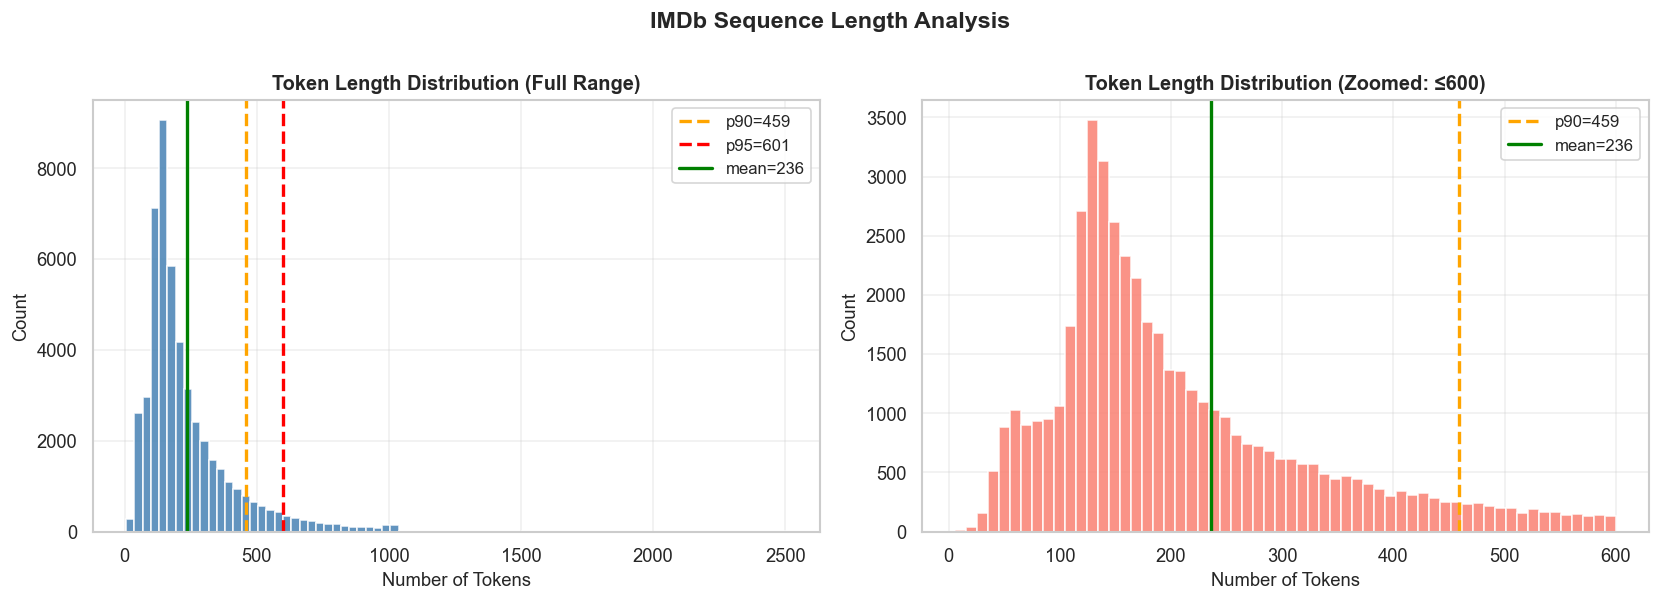


✓ RECOMMENDATION: max_len = 459 (90th percentile)
  This covers ~90% of reviews without excessive padding.
  Sequences longer than 459 will be truncated.


In [5]:
# Analyze sequence lengths using the preprocessing module
length_stats = analyze_sequence_lengths(cleaned_texts)

print('SEQUENCE LENGTH STATISTICS (tokens)')
print('=' * 50)
print(f'Minimum          : {length_stats["min"]:,}')
print(f'Maximum          : {length_stats["max"]:,}')
print(f'Mean             : {length_stats["mean"]:.1f}')
print(f'Median           : {length_stats["median"]:.1f}')
print(f'Std Dev          : {length_stats["std"]:.1f}')
print(f'90th percentile  : {length_stats["p90"]}')
print(f'95th percentile  : {length_stats["p95"]}')
print(f'99th percentile  : {length_stats["p99"]}')

# Histogram visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
lengths = length_stats['lengths']
axes[0].hist(lengths, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
for pct, val, col in [(90, length_stats['p90'], 'orange'), (95, length_stats['p95'], 'red')]:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=2, label=f'p{pct}={val}')
axes[0].axvline(length_stats['mean'], color='green', linestyle='-', linewidth=2, label=f'mean={length_stats["mean"]:.0f}')
axes[0].set_title('Token Length Distribution (Full Range)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Tokens', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Zoomed view (0-600 tokens covers ~95% of data)
zoomed_lengths = [l for l in lengths if l <= 600]
axes[1].hist(zoomed_lengths, bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(length_stats['p90'], color='orange', linestyle='--', linewidth=2, label=f'p90={length_stats["p90"]}')
axes[1].axvline(length_stats['mean'], color='green', linestyle='-', linewidth=2, label=f'mean={length_stats["mean"]:.0f}')
axes[1].set_title('Token Length Distribution (Zoomed: ≤600)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Tokens', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('IMDb Sequence Length Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/eda_sequence_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ RECOMMENDATION: max_len = {length_stats["p90"]} (90th percentile)')
print(f'  This covers ~90% of reviews without excessive padding.')
print(f'  Sequences longer than {length_stats["p90"]} will be truncated.')

## 5. EDA Req-3: Voculary Frequency

VOCABULARY FREQUENCY ANALYSIS
Total tokens (raw)           : 11,777,956
Unique words (raw)           : 101,242
After stopword removal       : 101,131 unique tokens
Frequency reduction          : 46.7%


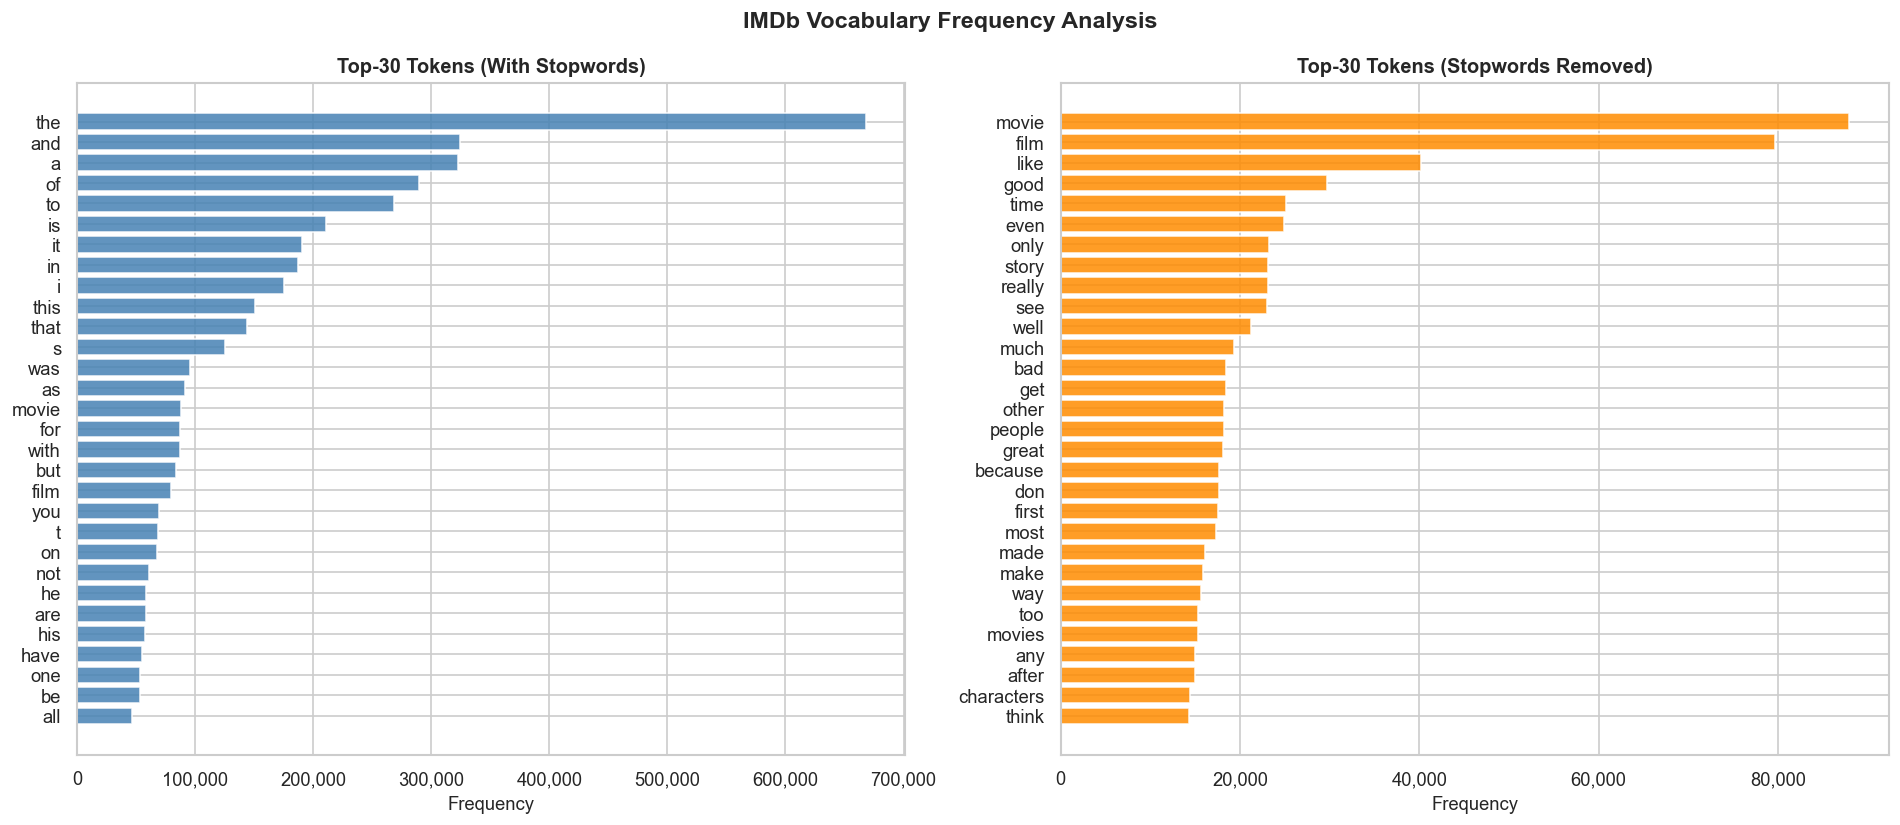


✓ CONCLUSION:
  Without removal: function words (the, a, and, is) dominate.
  With removal   : sentiment-rich words emerge (film, good, great, bad, story).
  Decision       : Stop-word removal beneficial for BoW model baseline.


In [6]:
# Get top-30 tokens using the preprocessing module
top_words, top_freqs = get_vocab_frequencies(cleaned_texts, top_n=30)

# Manual stop-word list (lightweight version)
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','it','this','that','i','he','she','they','we','you','be',
    'are','were','has','have','had','as','by','from','not','his','her',
    'their','its','my','your','our','so','if','do','did','will','would',
    'could','should','there','than','then','just','more','also','about',
    'up','out','one','what','which','who','all','no','been','very','into',
    'when','me','him','them','how','some','can','s','t','re','ll','ve','m'
])

# Get filtered tokens (with stopword removal)
all_tokens = [w for text in cleaned_texts for w in text.split()]
filtered_tokens = [t for t in all_tokens if t not in STOPWORDS and len(t) > 1]
freq_filtered = Counter(filtered_tokens)
top_words_filtered, top_freqs_filtered = zip(*freq_filtered.most_common(30))

print('VOCABULARY FREQUENCY ANALYSIS')
print('=' * 50)
print(f'Total tokens (raw)           : {len(all_tokens):,}')
print(f'Unique words (raw)           : {len(set(all_tokens)):,}')
print(f'After stopword removal       : {len(set(filtered_tokens)):,} unique tokens')
print(f'Frequency reduction          : {(1 - len(filtered_tokens)/len(all_tokens))*100:.1f}%')

# Visualization: side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Raw frequencies
axes[0].barh(list(reversed(top_words)), list(reversed(top_freqs)), 
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Top-30 Tokens (With Stopwords)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Filtered frequencies
axes[1].barh(list(reversed(top_words_filtered)), list(reversed(top_freqs_filtered)), 
             color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Top-30 Tokens (Stopwords Removed)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Frequency', fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.suptitle('IMDb Vocabulary Frequency Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_vocab_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✓ CONCLUSION:')
print(f'  Without removal: function words (the, a, and, is) dominate.')
print(f'  With removal   : sentiment-rich words emerge (film, good, great, bad, story).')
print(f'  Decision       : Stop-word removal beneficial for BoW model baseline.')

## 6. EDA Req-4: Representative samples

In [7]:
# Get representative samples using the preprocessing module
samples_by_class = get_representative_samples(cleaned_texts, raw_labels, n_per_class=4)

print('REPRESENTATIVE SAMPLES ANALYSIS')
print('=' * 80)

print('\nPOSITIVE REVIEWS (Label = 1)')
print('-' * 80)
for rank, sample in enumerate(samples_by_class[1], 1):
    tokens = len(sample.split())
    preview = sample[:250].replace('\n', ' ')
    print(f'\n[Positive Sample {rank}] — {tokens} tokens')
    print(f'"{preview}..."')

print('\n\nNEGATIVE REVIEWS (Label = 0)')
print('-' * 80)
for rank, sample in enumerate(samples_by_class[0], 1):
    tokens = len(sample.split())
    preview = sample[:250].replace('\n', ' ')
    print(f'\n[Negative Sample {rank}] — {tokens} tokens')
    print(f'"{preview}..."')

print('\n' + '=' * 80)

REPRESENTATIVE SAMPLES ANALYSIS

POSITIVE REVIEWS (Label = 1)
--------------------------------------------------------------------------------

[Positive Sample 1] — 127 tokens
"my father the hero used to be my favorite movie when i was younger it s about andre a divorced french man who wants to take his beautiful daughter katharine heigl on a vacation hoping to get a little closer to her but of course nicole isn t that easy..."

[Positive Sample 2] — 176 tokens
"after an anonymous phone call about a spacecraft that would have crashed in a frozen wood two police officers find evidences that the event really happened and apparently one martian had walked away from the spot they drive to the nearby hi way caf a..."

[Positive Sample 3] — 288 tokens
"i read the book written by bill carter on which this movie is based many years ago the book is certainly stronger than the movie it provides more detail than a movie can possibly provide the end result being that i thought the movie seemed a 

In [8]:
# Summary recommendations for preprocessing
print('╔══════════════════════════════════════════════════════════════════╗')
print('║                   EDA SUMMARY & RECOMMENDATIONS                 ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║  Dataset            : IMDb (50,000 total)                       ║')
print(f'║  Train/Test Split   : 25,000 / 25,000                          ║')
print(f'║  Class Balance      : Perfect (50% pos / 50% neg)               ║')
print(f'║  Avg Review Length  : {length_stats["mean"]:.0f} tokens                             ║')
print(f'║  → Recommended      : max_len = {length_stats["p90"]} (p90)                      ║')
print(f'║                                                                  ║')
print(f'║  Vocabulary Size    : {len(set(all_tokens)):,} unique tokens (with stopwords)    ║')
print(f'║  → Recommend        : 20,000 tokens (experiment: 10k/20k/30k)   ║')
print(f'║                                                                  ║')
print(f'║  Class Weighting    : Not needed (balanced dataset)              ║')
print(f'║  Oversampling       : Not needed (balanced dataset)              ║')
print(f'║  Stop-word Removal  : Beneficial (improves signal clarity)       ║')
print('╚══════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════╗
║                   EDA SUMMARY & RECOMMENDATIONS                 ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset            : IMDb (50,000 total)                       ║
║  Train/Test Split   : 25,000 / 25,000                          ║
║  Class Balance      : Perfect (50% pos / 50% neg)               ║
║  Avg Review Length  : 236 tokens                             ║
║  → Recommended      : max_len = 459 (p90)                      ║
║                                                                  ║
║  Vocabulary Size    : 101,242 unique tokens (with stopwords)    ║
║  → Recommend        : 20,000 tokens (experiment: 10k/20k/30k)   ║
║                                                                  ║
║  Class Weighting    : Not needed (balanced dataset)              ║
║  Oversampling       : Not needed (balanced dataset)              ║
║  Stop-word Removal  : Beneficial (improves si

In [9]:
# Quick reference: How to use preprocess.py for model training
print('QUICK REFERENCE: Using preprocess.py for model training\n')
print('=' * 70)

code_example = '''
# Option 1: Quick data preparation (all-in-one)
from preprocess import prepare_data

train_loader, val_loader, test_loader, vocab = prepare_data(
    max_vocab_size=20_000,  # or 10_000 / 30_000
    max_len=256,            # or 128 / 512
    batch_size=64,
    seed=42
)

# Option 2: Manual preparation with full control
from preprocess import (load_imdb_data, clean_text, build_vocab, 
                       SentimentDataset, collate_fn)
from torch.utils.data import DataLoader

# Load and clean
raw_texts, raw_labels = load_imdb_data()
texts = [clean_text(t) for t in raw_texts]

# Build vocabulary
vocab = build_vocab(texts, max_size=20_000)

# Create dataset and loader
dataset = SentimentDataset(texts, raw_labels, vocab, max_len=256)
loader = DataLoader(dataset, batch_size=64, collate_fn=collate_fn)

# Access batches
for batch_ids, batch_labels in loader:
    # batch_ids: [batch_size, seq_len_in_batch]
    # batch_labels: [batch_size]
    pass
'''

print(code_example)
print('=' * 70)

QUICK REFERENCE: Using preprocess.py for model training


# Option 1: Quick data preparation (all-in-one)
from preprocess import prepare_data

train_loader, val_loader, test_loader, vocab = prepare_data(
    max_vocab_size=20_000,  # or 10_000 / 30_000
    max_len=256,            # or 128 / 512
    batch_size=64,
    seed=42
)

# Option 2: Manual preparation with full control
from preprocess import (load_imdb_data, clean_text, build_vocab, 
                       SentimentDataset, collate_fn)
from torch.utils.data import DataLoader

# Load and clean
raw_texts, raw_labels = load_imdb_data()
texts = [clean_text(t) for t in raw_texts]

# Build vocabulary
vocab = build_vocab(texts, max_size=20_000)

# Create dataset and loader
dataset = SentimentDataset(texts, raw_labels, vocab, max_len=256)
loader = DataLoader(dataset, batch_size=64, collate_fn=collate_fn)

# Access batches
for batch_ids, batch_labels in loader:
    # batch_ids: [batch_size, seq_len_in_batch]
    # batch_labels: [batch_si